In [1]:
from pathlib import Path
import pickle
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

import eda_sol_reweight

In [2]:
def load_items(stimuli_dir: Path, trial_id: int) -> np.ndarray:
    csv_path = stimuli_dir / f"civ_items_trial_{trial_id}.csv"
    df = pd.read_csv(csv_path)
    numeric = df.drop(columns=["Name"], errors="ignore")
    return numeric.to_numpy(dtype=np.int64)

def get_eda_params(items: np.ndarray) -> dict:
    n_obj = items.shape[1] - 1

    if n_obj == 3:
        n_selected = 6
        max_row_diff = 5
    elif n_obj == 5:
        n_selected = 10
        max_row_diff = 500 ## should use different criteria for human guided eda (default is 500)
    else:
        raise ValueError(f"Number of objectives {n_obj} not supported")

    return {
        "n_items": items.shape[0],
        "n_obj": n_obj,
        "n_con": 1,
        "n_selected": n_selected,
        "capacity": n_selected * 10,
        "pop_size": 1_000,
        "generations": 100,
        "max_no_improve_gen": 5,
        "max_row_diff": max_row_diff,
    }

def run_eda_pass(items: np.ndarray, params: dict, 
                 seed: int, aspi: np.ndarray, if_rank: bool, temp: float) -> dict:
    eda_process = eda_sol_reweight.KnapsackEDA(
        items=items,
        capacity=params["capacity"],
        n_selected=params["n_selected"],
        n_obj=params["n_obj"],
        pop_size=params["pop_size"],
        generations=params["generations"],
        max_no_improve_gen=params["max_no_improve_gen"],
        max_row_diff=params["max_row_diff"],
        seed=seed,
        aspi=aspi,
        if_rank=if_rank,
        temp=temp
    )
    return eda_process.run()

def save_pass_results(run_name: str, results: dict, output_dir: Path) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / f"eda_human_reweight_{run_name}.pkl"

    with open(file_path, "wb") as f:
        pickle.dump(results, f)

    return file_path

In [3]:
def select_test_ref(trial_id: int) -> np.ndarray:
    with open(f'card_game/eda_results/eda_trial{trial_id}.pkl', 'rb') as f:
        results = pickle.load(f)
    pf_actual = results['converged_pf_table'][-1]
    # ref_sol = np.median(pf_actual, axis=0)
    q5 = np.percentile(pf_actual, 5, axis=0)
    q95 = np.percentile(pf_actual, 95, axis=0)
    ref_sol = np.array([q95[0], q95[1], q95[2], q5[3], q5[4]])
    return ref_sol, pf_actual

# def gen_aspi(ref_sol, pf_actual):
#     # normalize by 95 percentile
#     # q95 = np.percentile(pf_actual, 95, axis=0)
#     # aspi = ref_sol/q95

#     # normalize by z-score
#     # aspi = (ref_sol - np.mean(pf_actual, axis=0)) / np.std(pf_actual, axis=0)

#     # min-max quantile
#     q5 = np.percentile(pf_actual, 5, axis=0)
#     q95 = np.percentile(pf_actual, 95, axis=0)
#     aspi = (ref_sol - q5) / (q95 - q5 + 1e-12)

#     # robust scalar (ref_sol - q50) / (q75 - q25)
#     # scaler = RobustScaler()
#     # scaler.fit(pf_actual)
#     # aspi = scaler.transform(ref_sol.reshape(1, -1))[0]

#     return aspi

def gen_aspi(ref_sol, items):
    n_obj = items.shape[1] - 1
    if n_obj == 3:
        n_selected = 6
    elif n_obj == 5:
        n_selected = 10
    else:
        raise ValueError(f"Number of objectives {n_obj} not supported")

    items_q5 = np.percentile(items[:, :n_obj], 5, axis=0)
    items_q95 = np.percentile(items[:, :n_obj], 95, axis=0)
    aspi = (ref_sol - items_q5*n_selected) / (items_q95*n_selected - items_q5*n_selected + 1e-12)
    return aspi 

In [4]:
# obtain item list
trial_id = 9
stimuli_dir = Path("card_game/stimuli")
items = load_items(stimuli_dir=stimuli_dir, trial_id=trial_id)

# obtain params
params = get_eda_params(items)
n_obj = params["n_obj"]
if_rank = True
temp = 0.3

# generate aspiration vector
ref_sol, pf_actual = select_test_ref(trial_id)
aspi = gen_aspi(ref_sol, items)
aspi = aspi / (np.linalg.norm(aspi) + 1e-12)

In [5]:
# run EDA
run_name = "95_5_trial9_temp03"
results = run_eda_pass(
    items=items,
    params=params,
    seed=1127,
    aspi=aspi,
    if_rank=if_rank,
    temp=temp
)

# save results
output_dir = Path("data/eda_results/sol_reweight")
save_path = save_pass_results(run_name, results, output_dir)
pf = results["converged_pf_table"][-1]

# save info
file_path = output_dir / f"history_{run_name}.pkl"
history = {
    "trial_id": trial_id,
    "original_aspi": ref_sol,
    "normalized_aspi": aspi,
    "if_rank": if_rank,
    "temp": temp
}
with open(file_path, "wb") as f:
    pickle.dump(history, f)

Mode 1 generation 1 (no improve count: 0)
Mode 1 generation 2 (no improve count: 0)
Mode 1 generation 3 (no improve count: 1)
Mode 1 generation 4 (no improve count: 0)
Mode 1 generation 5 (no improve count: 0)
Mode 1 generation 6 (no improve count: 1)
Mode 1 generation 7 (no improve count: 0)
Mode 1 generation 8 (no improve count: 1)
Mode 1 generation 9 (no improve count: 0)
Mode 1 generation 10 (no improve count: 0)
Mode 1 generation 11 (no improve count: 1)
Mode 1 generation 12 (no improve count: 0)
Mode 1 generation 13 (no improve count: 0)
Mode 1 generation 14 (no improve count: 0)
Mode 1 generation 15 (no improve count: 0)
Mode 1 generation 16 (no improve count: 1)
Mode 1 generation 17 (no improve count: 0)
Mode 1 generation 18 (no improve count: 1)
Mode 1 generation 19 (no improve count: 2)
Mode 1 generation 20 (no improve count: 3)
Mode 1 generation 21 (no improve count: 0)
Mode 1 generation 22 (no improve count: 1)
Mode 1 generation 23 (no improve count: 2)
Mode 1 generation 24

In [8]:
# load results
run_name = "95_5_trial9"
trial_id = 9
stimuli_dir = Path("card_game/stimuli")
items = load_items(stimuli_dir=stimuli_dir, trial_id=trial_id)

with open(f"data/eda_results/sol_reweight/eda_human_reweight_{run_name}.pkl", "rb") as f:
    results = pickle.load(f)
pf = results["converged_pf_table"][-1]

with open(f"data/eda_results/sol_reweight/history_{run_name}.pkl", "rb") as f:
    history = pickle.load(f)
    ref_sol = history["original_aspi"]
    aspi = history["normalized_aspi"]

with open(f'card_game/eda_results/eda_trial{trial_id}.pkl', 'rb') as f:
        results = pickle.load(f)
pf_actual = results['converged_pf_table'][-1]

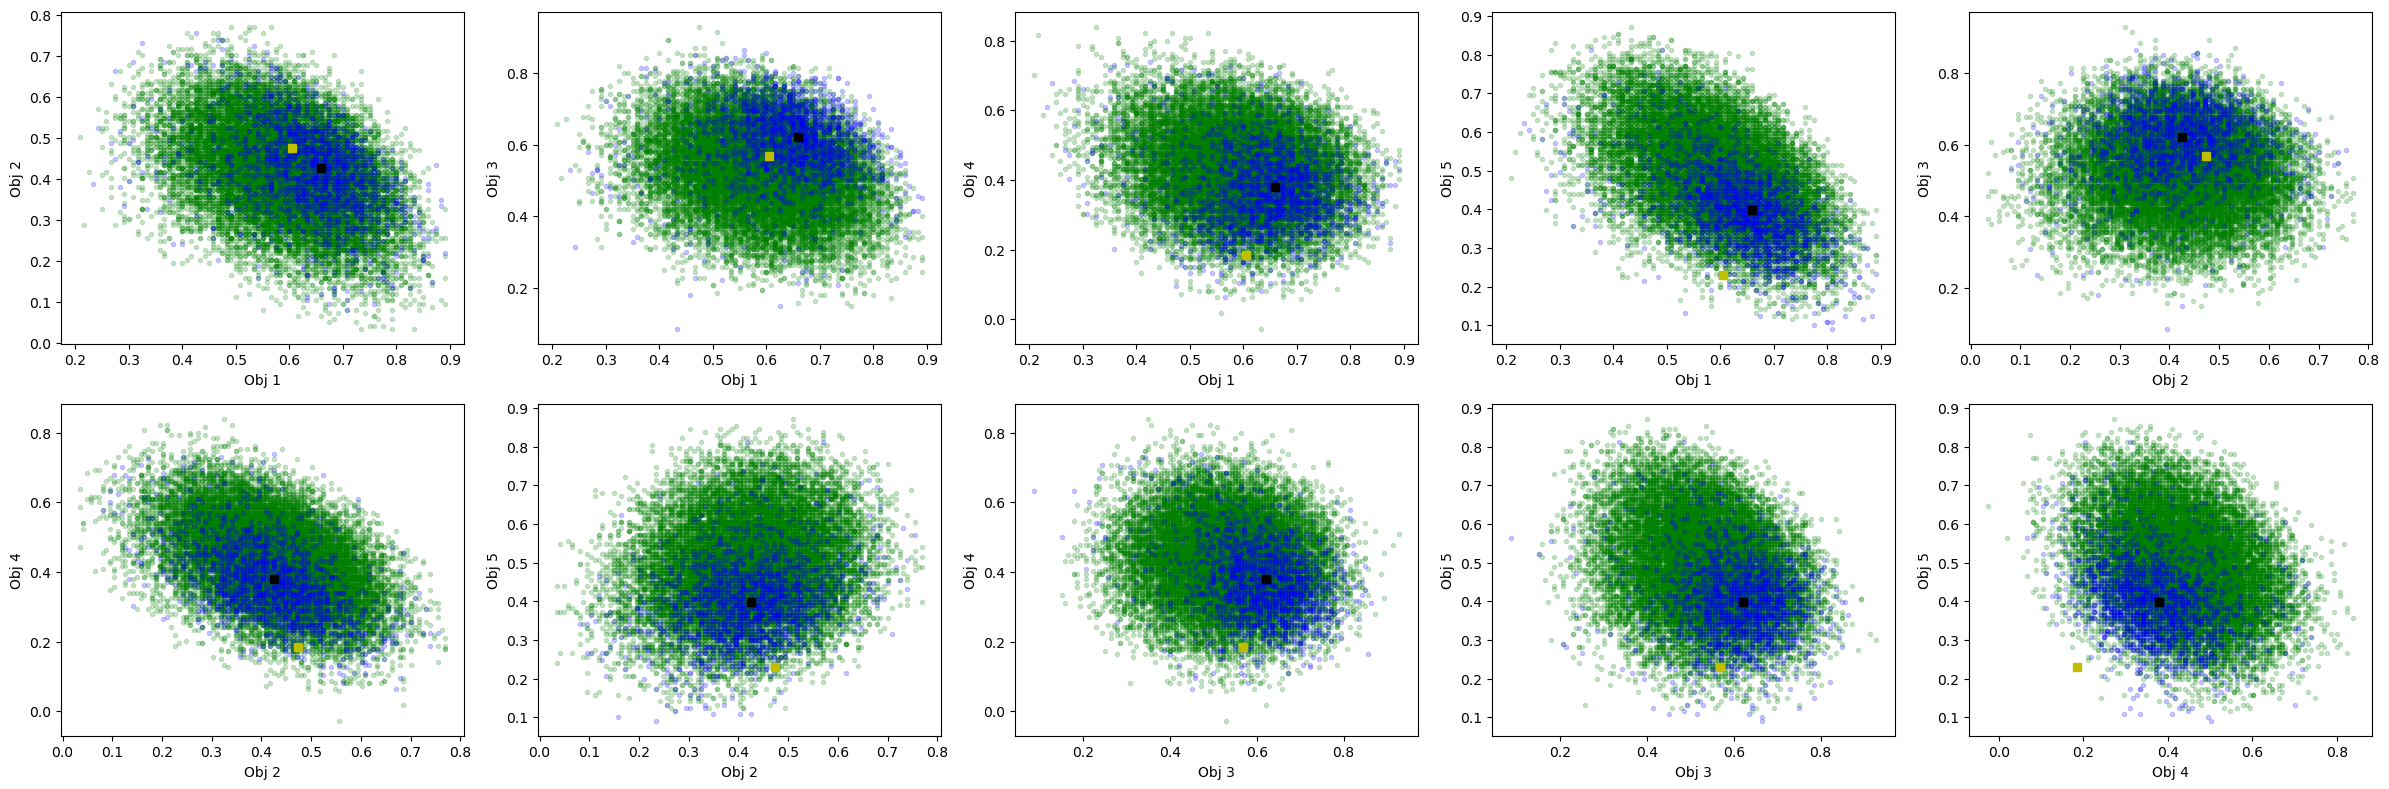

In [9]:
# normalize pf using min-max quantile
pf_norm = gen_aspi(pf, items)

# compute center solution then normalize it using min-max quantile
center = np.median(pf, axis=0)
dist = np.linalg.norm(pf - center, axis=1) 
center_sol = pf[dist.argmin()]
center_sol_norm = gen_aspi(center_sol, items)

# normalize pf_actual
pf_actual_norm = gen_aspi(pf_actual, items)

# plot normalized pf, normalized center, and aspiration 
objective_pairs = list(itertools.combinations(range(5), 2)) 
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.ravel()
for ax, (a, b) in zip(axes, objective_pairs):
    ax.plot(pf_actual_norm[:, a], pf_actual_norm[:, b], "go", alpha=0.2, markersize=3, label="PF")
    ax.plot(pf_norm[:, a], pf_norm[:, b], "bo", alpha=0.2, markersize=3, label="PF")
    ax.plot(
        aspi[a], aspi[b],
        "ys", alpha=1, markersize=6, label="Aspiration"
    )
    ax.plot(
        center_sol_norm[a], center_sol_norm[b],
        "ks", alpha=1, markersize=6, label="Center"
    )
    ax.set_xlabel(f"Obj {a + 1}")
    ax.set_ylabel(f"Obj {b + 1}")
    # ax.set_xlim(0.0, 0.9)
    # ax.set_ylim(0.0, 0.9)
    
fig.tight_layout()
plt.show()